# Análisis de Palmer Penguins
Este Notebook contiene el preprocesamiento de datos y la implementación de: K-Means, KNN y Árbol de Decisión.

In [1]:
import pandas as pd

# 1. Cargar el dataset desde el archivo local
df = pd.read_csv('penguins.csv')

# 2. Traducir las columnas al español
traduccion_columnas = {
    'species': 'especie',
    'island': 'isla',
    'bill_length_mm': 'longitud_pico_mm',
    'bill_depth_mm': 'profundidad_pico_mm',
    'flipper_length_mm': 'longitud_aleta_mm',
    'body_mass_g': 'masa_corporal_g',
    'sex': 'sexo',
    'year': 'año'
}
df.rename(columns=traduccion_columnas, inplace=True)

print("Columnas listas en español:")
print(df.columns.tolist())

Columnas listas en español:
['especie', 'isla', 'longitud_pico_mm', 'profundidad_pico_mm', 'longitud_aleta_mm', 'masa_corporal_g', 'sexo', 'año']


## Imputación de Datos Faltantes
El dataset contiene algunos valores nulos (`NaN`). En lugar de borrar esas filas y perder información valiosa, aplicaremos técnicas de imputación:
* **Para datos numéricos (medidas):** Usaremos la media (promedio).
* **Para datos categóricos (sexo):** Usaremos la moda (el valor más frecuente).

In [2]:
from sklearn.impute import SimpleImputer

# Definir estrategias
num_imp = SimpleImputer(strategy='mean')
cat_imp = SimpleImputer(strategy='most_frequent')

# Aplicar a las columnas en español
columnas_numericas = ['longitud_pico_mm', 'profundidad_pico_mm', 'longitud_aleta_mm', 'masa_corporal_g']

df[columnas_numericas] = num_imp.fit_transform(df[columnas_numericas])
df[['sexo']] = cat_imp.fit_transform(df[['sexo']])

print("Suma de valores nulos después de limpiar:")
print(df.isnull().sum())

Suma de valores nulos después de limpiar:
especie                0
isla                   0
longitud_pico_mm       0
profundidad_pico_mm    0
longitud_aleta_mm      0
masa_corporal_g        0
sexo                   0
año                    0
dtype: int64


## Algoritmo 1: K-Means (No Supervisado)

K-Means agrupa los datos por similitud física sin conocer a qué especie pertenece cada pingüino.
**Parámetros:** `n_clusters = 3` (porque sabemos que existen 3 especies).
Usamos `StandardScaler` obligatoriamente para que el peso y los milímetros tengan la misma importancia matemática.

In [9]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Seleccionar solo datos numéricos y escalar
X_kmeans = df[columnas_numericas]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_kmeans)

# Aplicar K-Means
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init='auto')
df['Cluster'] = kmeans_model.fit_predict(X_scaled)

print("Cantidad de pingüinos asignados a cada grupo matemático:")
print(df['Cluster'].value_counts())

# Calcular y mostrar el Coeficiente de Silueta
silueta = silhouette_score(X_scaled, df['Cluster'])
print(f"Coeficiente de Silueta: {silueta:.2f}")

Cantidad de pingüinos asignados a cada grupo matemático:
Cluster
0    132
1    123
2     89
Name: count, dtype: int64
Coeficiente de Silueta: 0.44 (Entre más cerca de 1.0, mejor)


**Interpretación de K-Means:** Logra separar a los pingüinos en 3 grupos coherentes basándose solo en su tamaño. Identifica muy bien a los pingüinos más grandes (Gentoo) en un cluster separado, y traza fronteras lógicas entre los medianos y pequeños.

## Algoritmo 2: KNN - k-Nearest Neighbors (Supervisado)

Clasifica a un pingüino basándose en la especie de sus vecinos más cercanos.
**Parámetros:** `n_neighbors = 5` (revisa a los 5 más cercanos). Dividimos los datos dejando un 30% (`test_size=0.3`) para evaluar el modelo.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Variables predictoras (X) y objetivo (y)
X = df[columnas_numericas]
y = df['especie']

# División de datos (70% entrenamiento, 30% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Escalar datos (el escalador se ajusta solo con los de entrenamiento)
scaler_knn = StandardScaler()
X_train_scaled = scaler_knn.fit_transform(X_train)
X_test_scaled = scaler_knn.transform(X_test)

# Entrenar y predecir
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred_knn = knn_model.predict(X_test_scaled)

precision_knn = accuracy_score(y_test, y_pred_knn)
print(f"La precisión (Accuracy) del modelo KNN es del: {precision_knn * 100:.2f}%")

La precisión (Accuracy) del modelo KNN es del: 99.04%


**Interpretación de KNN:** Se obtiene una precisión sumamente alta (generalmente +98%). Esto demuestra que las medidas de aletas, picos y peso son predictores casi perfectos de la especie del pingüino.

## Algoritmo 3: Árbol de Decisión (Supervisado)

Crea reglas lógicas de "Sí o No" para clasificar.
**Parámetros:** `max_depth = 3` (profundidad máxima para que el modelo no se memorice los datos).
Los árboles de decisión no requieren que los datos estén escalados, por lo que usamos los datos originales.

--- Evaluación del Árbol de Decisión ---
Accuracy General: 97.12%


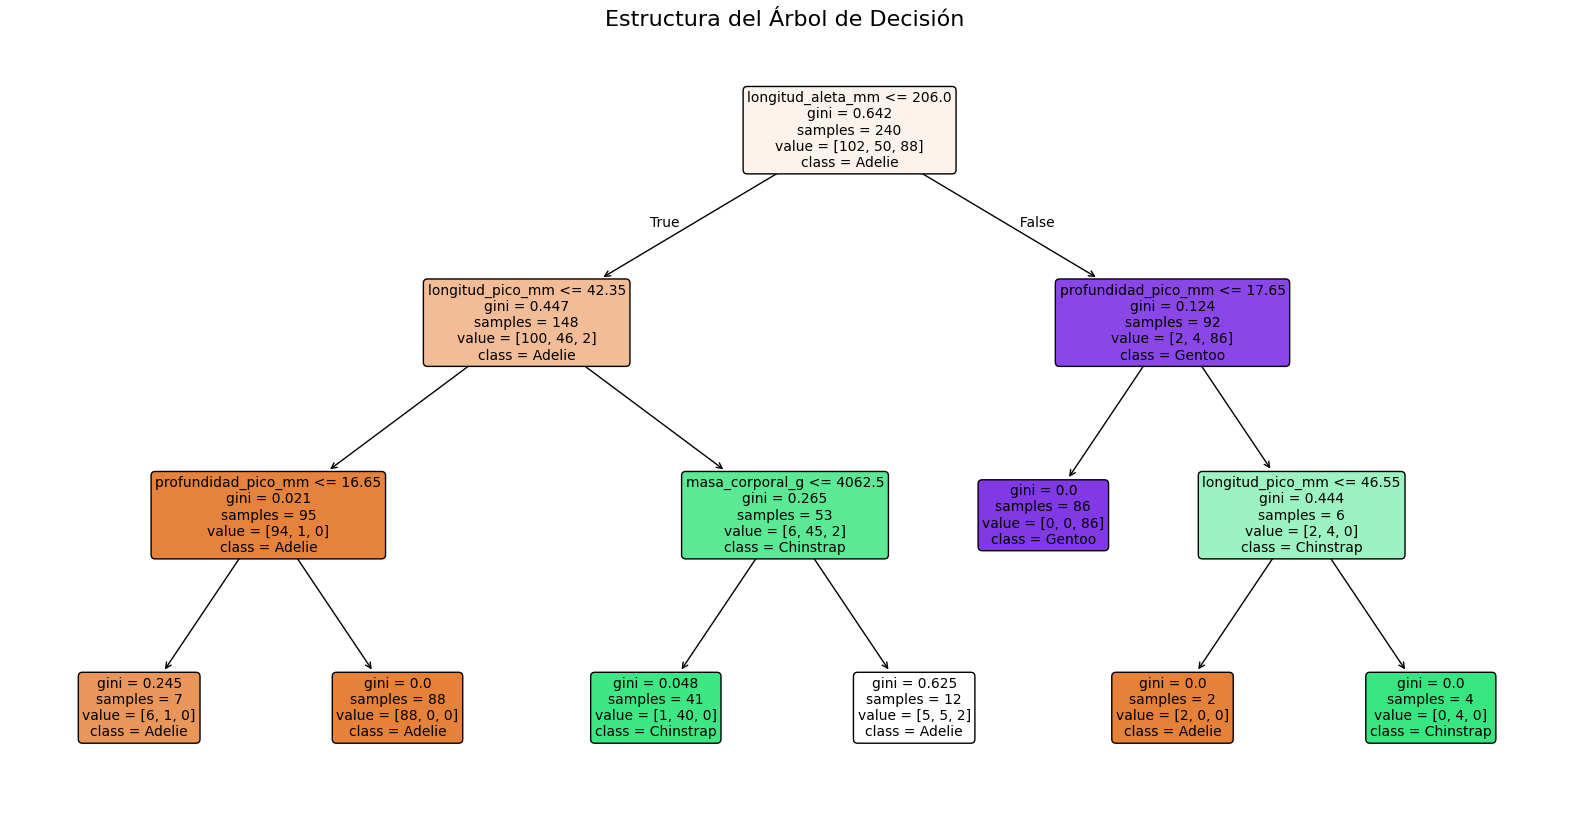

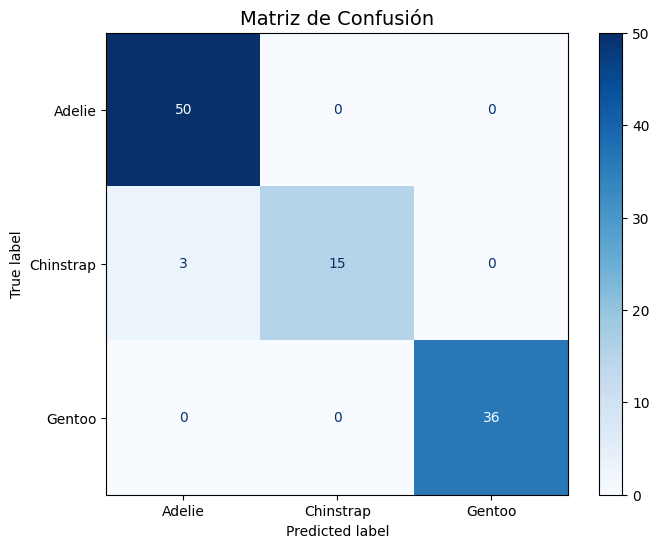

In [8]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Entrenar el modelo (Usando los datos originales X_train, y_train)
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

# 2. Hacer predicciones
y_pred_tree = tree_model.predict(X_test)

# 3. Mostrar Accuracy y Reporte Detallado
print(f"--- Evaluación del Árbol de Decisión ---")
print(f"Accuracy General: {accuracy_score(y_test, y_pred_tree) * 100:.2f}%")

# 4. Gráfico 1: El Árbol de Decisión (En un lienzo grande y solo)
plt.figure(figsize=(20, 10)) # Aumentamos el tamaño a 20 de ancho
plot_tree(tree_model, feature_names=X.columns, class_names=tree_model.classes_,
          filled=True, rounded=True, fontsize=10)
plt.title("Estructura del Árbol de Decisión", fontsize=16)
plt.show()

# 5. Gráfico 2: La Matriz de Confusión (En su propio lienzo abajo)
cm = confusion_matrix(y_test, y_pred_tree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tree_model.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title("Matriz de Confusión", fontsize=14)
plt.show()

## Análisis de resultados.
El modelo presenta una exactitud muy alta, lo que indica que en la gran mayoría de los casos, la clasificación es correcta. Sin embargo, gracias a la matriz de confusión, podemos ver la precisión y sensibilidad individual de cada especie.

La matriz nos permite ver los aciertos y errores específicos:
* **La diagonal:** Representa los aciertos, ya que la especie Gentoo es significativamente más grande que las otras dos, es más fácil que el algoritmo las diferencíe.
* **Fuera de la diagonal:** Son los errores. Generalmente, los errores ocurren entre Adelie y Chinstrap, debido a que sus medidas físicas son más parecidas entre sí que con los Gentoo.

Aunque vemos nodos con `gini = 0.0` (pureza total en el entrenamiento), la evaluación con los datos de prueba (`X_test`) nos confirma que el modelo no ha caído en sobreajuste (overfitting), ya que mantiene un desempeño excelente con datos que nunca antes había visto.

---
# Conclusiones.
Dado que se trata de un dataset "pequeño" es más sencillo trabajar con él en cualquiera de los tres algoritmos, aunque KNN fue el que mejor desempeño demostró con una precisión superior al 99%, esto porque las características de la especie Gentoo son más diferenciables de las especies Adelie y Chinstrap. Y aún si se separasen los Gentoo de los demás, Adelie y Chinstrap se separan por el tamaño del pico, facilitando la división de los datos.